In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

---
**Answers:**

1. It is "linear" in its parameters (coefficients), meaning predictions are a linear combination of features multiplied by weights, even if the features themselves are nonlinear transformations.
2. Drop one category to avoid the dummy variable trap. The intercept becomes the mean of the reference category, and the dummy coefficient represents the average difference between that category and the reference.
3. Yes, but it's not recommended. Liner regression can regress a binary target, but it can predict impossible probabilities (<0 or >1).
4. High training accuracy but low testing accuracy, overly large coefficient magnitudes, or too many features relative to the sample size.
5. Regressing one feature on the others and getting a high $R^2$ means that feature is highly predictable by the rest. This inflates coefficient variance (VIF), making individual effects impossible to isolate.
6. Apply feature transformations before fitting, such as adding polynomial terms ($x^2$), logarithms ($\log(x)$), or interaction terms ($x_1 \times x_2$).
7. The expected change in $y$ for a one-unit increase in $x$, holding all other variables constant.
8. A train/test split divides data once. $k$-fold CV partitions data into $k$ subsets, iteratively training on $k-1$ and testing on 1, providing a less biased performance estimate but will take longer to compute.
9. Typically 5 or 10, offering the best trade-off between computational cost, bias, and variance.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

---
**Answers:**

* **Part 2:** If keeping the intercept, drop one category; coefficients are differences from the dropped reference mean. If dropping the intercept, keep all dummies; coefficients equal each neighborhood's average price.
* **Part 3:** The expected price change for a 1-point rating increase, ignoring other factors.
* **Part 4:** The slope is now the expected price change for a 1-point rating increase *within the same neighborhood*. Neighborhood averages adjust for rating differences across boroughs.
* **Part 5:** If slopes are similar, ratings affect prices equally everywhere. If different, the market value of a good rating depends on the specific neighborhood it is in.

Averages by Neighbourhood:
                     Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750

Most expensive borough on average: Manhattan


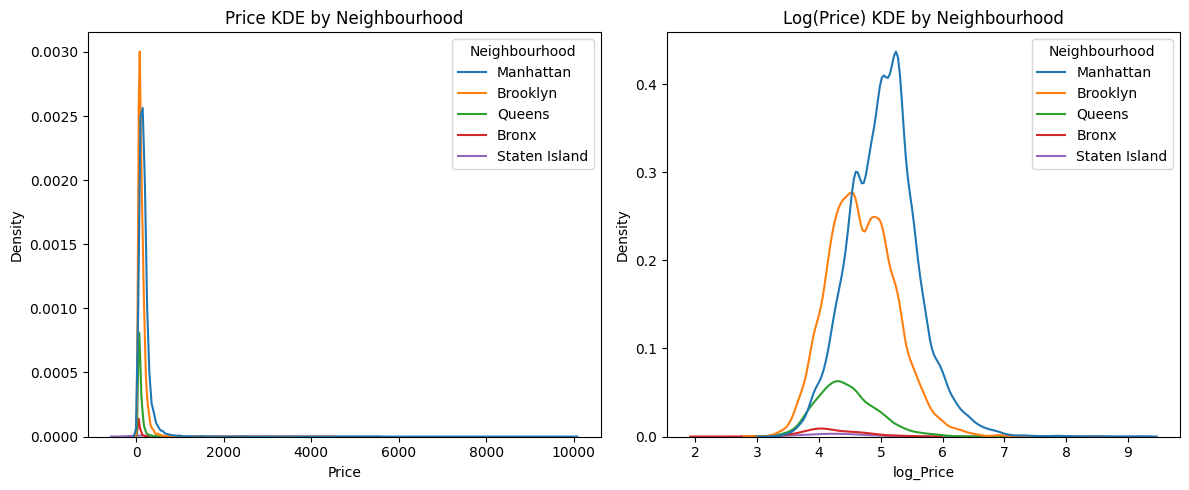

In [18]:
# Q2.1
q2_df = pd.read_csv('../data/Q1_clean.csv')
q2_df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True, errors='ignore')

_q2_summary = q2_df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Averages by Neighbourhood:\n", _q2_summary)
print("\nMost expensive borough on average:", _q2_summary['Price'].idxmax())

q2_df['log_Price'] = np.log(q2_df['Price'] + 1)

_fig, _axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=q2_df, x='Price', hue='Neighbourhood', ax=_axes[0])
_axes[0].set_title('Price KDE by Neighbourhood')

sns.kdeplot(data=q2_df, x='log_Price', hue='Neighbourhood', ax=_axes[1])
_axes[1].set_title('Log(Price) KDE by Neighbourhood')
plt.tight_layout()
plt.show()

In [19]:
# Q2.2
# Dropping the first category and keeping the intercept
_X_dummy = pd.get_dummies(q2_df[['Neighbourhood']], drop_first=True)
_y_2 = q2_df['Price']
_model_q2_2 = LinearRegression().fit(_X_dummy, _y_2)

print("Q2.2 Intercept (Base Category Mean):", _model_q2_2.intercept_)
print("Q2.2 Coefficients (Differences from Base):\n", pd.Series(_model_q2_2.coef_, index=_X_dummy.columns))

Q2.2 Intercept (Base Category Mean): 75.27649769585331
Q2.2 Coefficients (Differences from Base):
 Neighbourhood_Brooklyn          52.470881
Neighbourhood_Manhattan        108.387789
Neighbourhood_Queens            21.580735
Neighbourhood_Staten Island     70.890169
dtype: float64


In [20]:
# Q2.3
_X_rating = q2_df[['Review Scores Rating']]
_y_3 = q2_df['Price']
_model_q2_3 = LinearRegression().fit(_X_rating, _y_3)

print("Q2.3 Intercept:", _model_q2_3.intercept_)
print("Q2.3 Slope for Rating:", _model_q2_3.coef_[0])

Q2.3 Intercept: 60.878390657123546
Q2.3 Slope for Rating: 1.0208266022674763


In [21]:
# Q2.4
q2_X_both = pd.get_dummies(q2_df[['Neighbourhood', 'Review Scores Rating']], columns=['Neighbourhood'], drop_first=True)
q2_y = q2_df['Price']
_model_q2_4 = LinearRegression().fit(q2_X_both, q2_y)

print("Q2.4 Intercept:", _model_q2_4.intercept_)
print("Q2.4 Coefficients:\n", pd.Series(_model_q2_4.coef_, index=q2_X_both.columns))

Q2.4 Intercept: -23.812561011673324
Q2.4 Coefficients:
 Review Scores Rating             1.081116
Neighbourhood_Brooklyn          51.704240
Neighbourhood_Manhattan        108.228737
Neighbourhood_Queens            21.694600
Neighbourhood_Staten Island     71.766552
dtype: float64


In [22]:
# Q2.5
# Separate slope for each neighborhood for Review Scores Rating. 
_X_interact = pd.get_dummies(q2_df[['Neighbourhood']], columns=['Neighbourhood'], drop_first=False)
for _col in _X_interact.columns:
    _X_interact[_col] = _X_interact[_col].astype(float) * q2_df['Review Scores Rating']

q2_X_interact = _X_interact
_model_q2_5 = LinearRegression().fit(q2_X_interact, q2_y)

print("Q2.5 Intercept:", _model_q2_5.intercept_)
print("Q2.5 Slopes by Neighbourhood:\n", pd.Series(_model_q2_5.coef_, index=q2_X_interact.columns))

Q2.5 Intercept: 55.11825364116355
Q2.5 Slopes by Neighbourhood:
 Neighbourhood_Bronx            0.222718
Neighbourhood_Brooklyn         0.790947
Neighbourhood_Manhattan        1.399376
Neighbourhood_Queens           0.456451
Neighbourhood_Staten Island    0.682444
dtype: float64


In [23]:
# Q2.6
_cv_2 = KFold(n_splits=10, shuffle=True, random_state=42)
_model_cv = LinearRegression()

_scores_m4 = cross_val_score(_model_cv, q2_X_both, q2_y, cv=_cv_2, scoring='neg_mean_squared_error')
_scores_m5 = cross_val_score(_model_cv, q2_X_interact, q2_y, cv=_cv_2, scoring='neg_mean_squared_error')

print("Model 4 (Q2.4 - additive) CV MSE:", -np.mean(_scores_m4))
print("Model 5 (Q2.5 - interaction) CV MSE:", -np.mean(_scores_m5))

Model 4 (Q2.4 - additive) CV MSE: 21070.810022391735
Model 5 (Q2.5 - interaction) CV MSE: 21048.928267875694


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

---
**Answers:**

* **Part 2:** A linear slope assumes a constant price change per additional seat. One-hot encoding captures non-linear price jumps (such as the difference between a 2-seat and 4-seat sedan) which shows the effect is not always linear.

Price Summary:
 count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Price by Body_Type:
            count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  29410

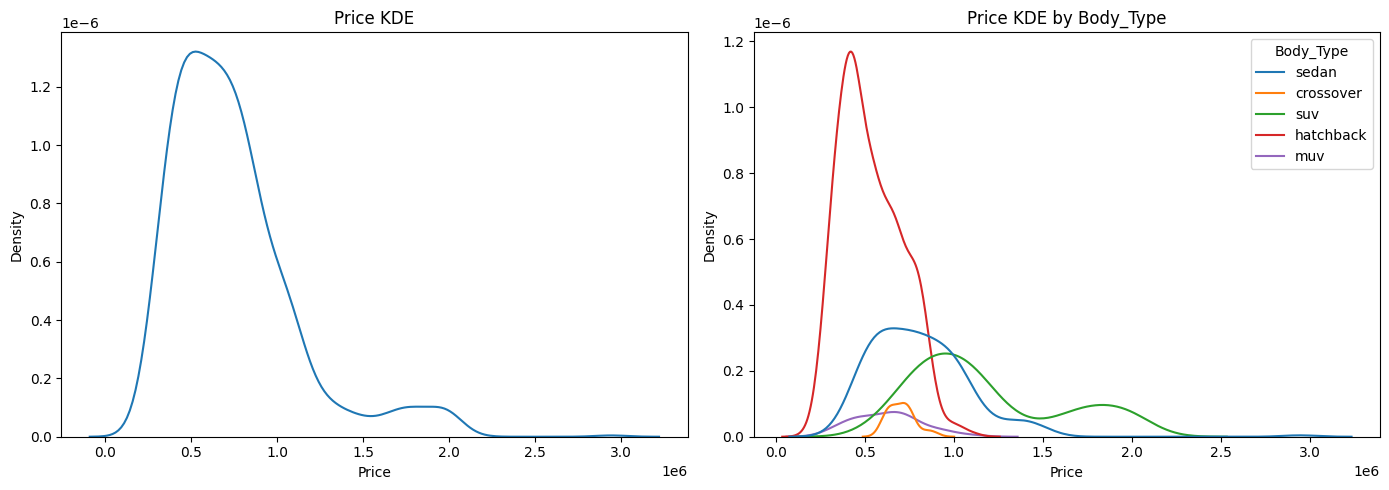

In [24]:
# Q3.1
q3_df = pd.read_csv('../data/cars_hw.csv')
print("Price Summary:\n", q3_df['Price'].describe())

_fig3, _axes3 = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=q3_df, x='Price', ax=_axes3[0])
_axes3[0].set_title('Price KDE')

print("\nPrice by Body_Type:\n", q3_df.groupby('Body_Type')['Price'].describe())

sns.kdeplot(data=q3_df, x='Price', hue='Body_Type', ax=_axes3[1])
_axes3[1].set_title('Price KDE by Body_Type')
plt.tight_layout()
plt.show()

In [25]:
# Q3.2
_X_seat_lin = q3_df[['Seating_Capacity']]
_y_cars = q3_df['Price']
_model_lin = LinearRegression().fit(_X_seat_lin, _y_cars)
print("Linear Slope for Seating Capacity:", _model_lin.coef_[0])

_X_seat_cat = pd.get_dummies(q3_df[['Seating_Capacity']], columns=['Seating_Capacity'], drop_first=True)
_model_cat = LinearRegression().fit(_X_seat_cat, _y_cars)
print("\nCategorical Coefficients for Seating Capacity (Difference from base):\n", pd.Series(_model_cat.coef_, index=_X_seat_cat.columns))

Linear Slope for Seating Capacity: 59267.99803672175

Categorical Coefficients for Seating Capacity (Difference from base):
 Seating_Capacity_5    5.464839e+05
Seating_Capacity_6    1.456000e+06
Seating_Capacity_7    7.359487e+05
Seating_Capacity_8    2.718000e+05
dtype: float64


In [26]:
# Q3.3
q3_df_age = q3_df.copy()
q3_df_age['Age'] = 2026 - q3_df_age['Make_Year']

_X_age = q3_df_age[['Age']]
_y_cars = q3_df_age['Price']

_cv_3 = KFold(n_splits=10, shuffle=True, random_state=42)
_degrees =[1, 2, 3, 4, 5]
q3_best_deg = 1
_best_score = float('inf')

print("CV MSE by Polynomial Degree:")
for _d in _degrees:
    _poly = PolynomialFeatures(degree=_d, include_bias=False)
    _X_poly = _poly.fit_transform(_X_age)
    _model_poly = LinearRegression()
    _scores = -cross_val_score(_model_poly, _X_poly, _y_cars, cv=_cv_3, scoring='neg_mean_squared_error')
    _mean_mse = np.mean(_scores)
    print(f"Degree {_d}: {_mean_mse}")
    if _mean_mse < _best_score:
        _best_score = _mean_mse
        q3_best_deg = _d

print(f"\nOptimal number of powers of Age: {q3_best_deg}")

CV MSE by Polynomial Degree:
Degree 1: 97377248063.9968
Degree 2: 97395705968.63509
Degree 3: 96743204818.44339
Degree 4: 96225038252.27266
Degree 5: 95265035513.63545

Optimal number of powers of Age: 5


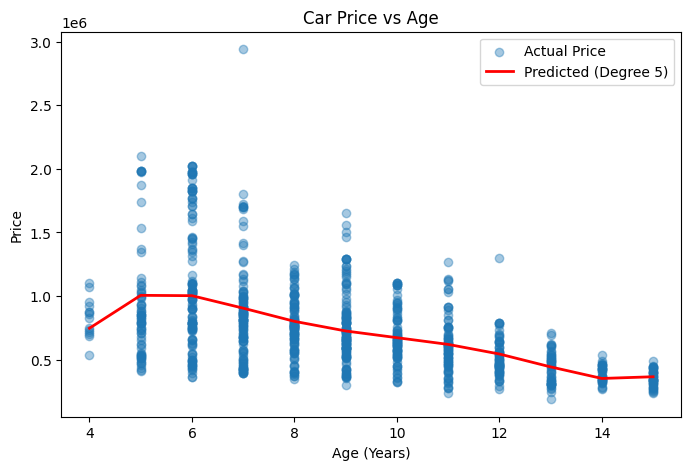

In [27]:
# Q3.4
_X_age_final = q3_df_age[['Age']]
_y_cars_final = q3_df_age['Price']

_poly_final = PolynomialFeatures(degree=q3_best_deg, include_bias=False)
_X_poly_final = _poly_final.fit_transform(_X_age_final)
_model_final = LinearRegression().fit(_X_poly_final, _y_cars_final)

_sort_idx = np.argsort(q3_df_age['Age'].values)
_age_sorted = q3_df_age['Age'].values[_sort_idx]
_preds_sorted = _model_final.predict(_X_poly_final)[_sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(q3_df_age['Age'], q3_df_age['Price'], alpha=0.4, label='Actual Price')
plt.plot(_age_sorted, _preds_sorted, color='red', linewidth=2, label=f'Predicted (Degree {q3_best_deg})')
plt.xlabel('Age (Years)')
plt.ylabel('Price')
plt.title('Car Price vs Age')
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

---
**Answers:**

* **Part 2:** The intercept equals the control group's survival proportion. The slope equals the treatment mean minus control mean.
* **Part 3:** Controlling for age removes omitted variable bias. The ATE underestimates the effect for younger patients and overestimates it for older ones.
* **Part 4:** An interaction allows the treatment effect to vary by age, revealing that transplants are better for younger patients and less effective for older ones.
* **Part 6:** My concerns are bias (reinforcing socioeconomic inequalities), extrapolation (inaccurate at extreme ages), and ethics (algorithmic denial of life-saving care ignores patient context).

In [28]:
# Q4.1
q4_df = pd.read_csv('../data/heart_hw.csv')
_control_surv = q4_df[q4_df['transplant'] == 'control']['y'].mean()
_treat_surv = q4_df[q4_df['transplant'] == 'treatment']['y'].mean()
q4_ate = _treat_surv - _control_surv

print("Control survival proportion:", _control_surv)
print("Treatment survival proportion:", _treat_surv)
print("Average Treatment Effect (ATE):", q4_ate)

Control survival proportion: 0.11764705882352941
Treatment survival proportion: 0.34782608695652173
Average Treatment Effect (ATE): 0.23017902813299232


In [29]:
# Q4.2
_X_trans = pd.get_dummies(q4_df[['transplant']], drop_first=True) 
q4_y_heart = q4_df['y']
_model_q4_2 = LinearRegression().fit(_X_trans, q4_y_heart)

print("Q4.2 Intercept:", _model_q4_2.intercept_)
print("Q4.2 Transplant Coefficient:", _model_q4_2.coef_[0])

Q4.2 Intercept: 0.1176470588235293
Q4.2 Transplant Coefficient: 0.23017902813299249


Q4.3 Intercept: 0.7019569721740946
Q4.3 Coefficients:
 age                    -0.013607
transplant_treatment    0.264702
dtype: float64


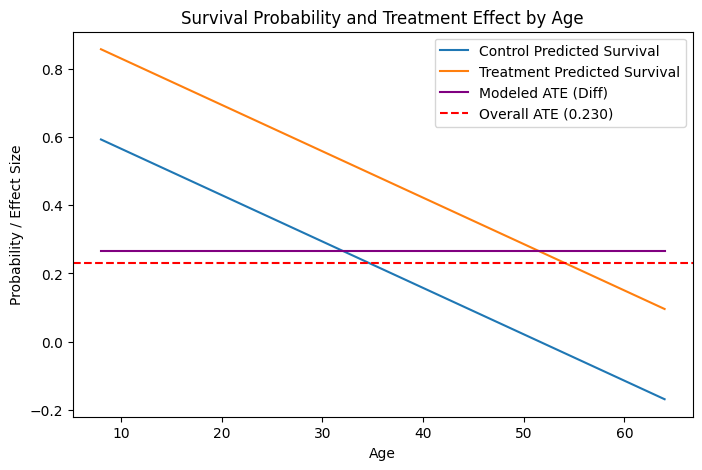

In [30]:
# Q4.3
q4_X_3 = pd.get_dummies(q4_df[['transplant', 'age']], columns=['transplant'], drop_first=True)
_model_q4_3 = LinearRegression().fit(q4_X_3, q4_y_heart)

print("Q4.3 Intercept:", _model_q4_3.intercept_)
print("Q4.3 Coefficients:\n", pd.Series(_model_q4_3.coef_, index=q4_X_3.columns))

_t_col_3 =[c for c in q4_X_3.columns if 'transplant' in c][0]
_ages = np.linspace(q4_df['age'].min(), q4_df['age'].max(), 100)

_pred_df_control_3 = pd.DataFrame({'age': _ages, _t_col_3: 0})[q4_X_3.columns]
_pred_df_treat_3 = pd.DataFrame({'age': _ages, _t_col_3: 1})[q4_X_3.columns]

_control_preds_3 = _model_q4_3.predict(_pred_df_control_3)
_treatment_preds_3 = _model_q4_3.predict(_pred_df_treat_3)

plt.figure(figsize=(8, 5))
plt.plot(_ages, _control_preds_3, label='Control Predicted Survival')
plt.plot(_ages, _treatment_preds_3, label='Treatment Predicted Survival')
plt.plot(_ages, _treatment_preds_3 - _control_preds_3, label='Modeled ATE (Diff)', color='purple')
plt.axhline(q4_ate, color='red', linestyle='--', label=f'Overall ATE ({q4_ate:.3f})')
plt.xlabel('Age')
plt.ylabel('Probability / Effect Size')
plt.title('Survival Probability and Treatment Effect by Age')
plt.legend()
plt.show()

Q4.4 Intercept: 0.35486517529946177
Q4.4 Coefficients:
 age                    -0.005524
transplant_treatment    0.907751
transplant_x_age       -0.014591
dtype: float64


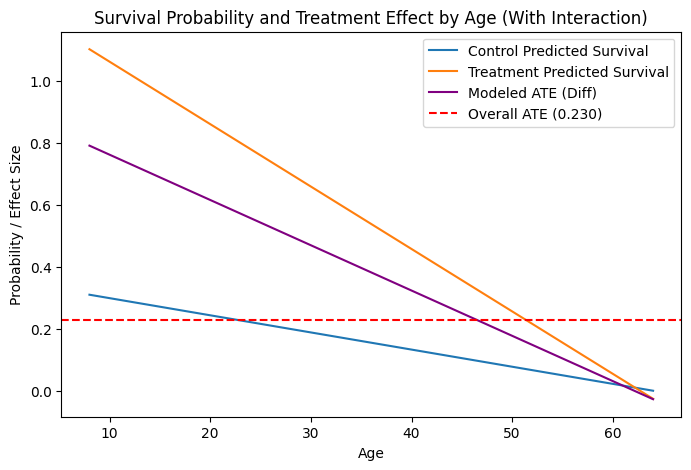

In [31]:
# Q4.4
_X_q4_4_base = pd.get_dummies(q4_df[['transplant', 'age']], columns=['transplant'], drop_first=True)
_t_col_4 =[c for c in _X_q4_4_base.columns if 'transplant' in c][0]

q4_X_4 = _X_q4_4_base.copy()
q4_X_4['transplant_x_age'] = q4_X_4[_t_col_4] * q4_X_4['age']

_model_q4_4 = LinearRegression().fit(q4_X_4, q4_y_heart)

print("Q4.4 Intercept:", _model_q4_4.intercept_)
print("Q4.4 Coefficients:\n", pd.Series(_model_q4_4.coef_, index=q4_X_4.columns))

_ages_4 = np.linspace(q4_df['age'].min(), q4_df['age'].max(), 100)
_pred_df_control_4 = pd.DataFrame({'age': _ages_4, _t_col_4: 0, 'transplant_x_age': 0})[q4_X_4.columns]
_pred_df_treat_4 = pd.DataFrame({'age': _ages_4, _t_col_4: 1, 'transplant_x_age': _ages_4})[q4_X_4.columns]

_control_preds_4 = _model_q4_4.predict(_pred_df_control_4)
_treatment_preds_4 = _model_q4_4.predict(_pred_df_treat_4)

plt.figure(figsize=(8, 5))
plt.plot(_ages_4, _control_preds_4, label='Control Predicted Survival')
plt.plot(_ages_4, _treatment_preds_4, label='Treatment Predicted Survival')
plt.plot(_ages_4, _treatment_preds_4 - _control_preds_4, label='Modeled ATE (Diff)', color='purple')
plt.axhline(q4_ate, color='red', linestyle='--', label=f'Overall ATE ({q4_ate:.3f})')
plt.xlabel('Age')
plt.ylabel('Probability / Effect Size')
plt.title('Survival Probability and Treatment Effect by Age (With Interaction)')
plt.legend()
plt.show()

In [32]:
# Q4.5
_cv_4 = KFold(n_splits=10, shuffle=True, random_state=42)
_model_cv_4 = LinearRegression()

_scores_m3 = cross_val_score(_model_cv_4, q4_X_3, q4_y_heart, cv=_cv_4, scoring='neg_mean_squared_error')
_scores_m4 = cross_val_score(_model_cv_4, q4_X_4, q4_y_heart, cv=_cv_4, scoring='neg_mean_squared_error')

print("Model 3 (Age controlled) CV MSE:", -np.mean(_scores_m3))
print("Model 4 (Age interaction) CV MSE:", -np.mean(_scores_m4))

Model 3 (Age controlled) CV MSE: 0.17726651658550785
Model 4 (Age interaction) CV MSE: 0.17512042221989677
